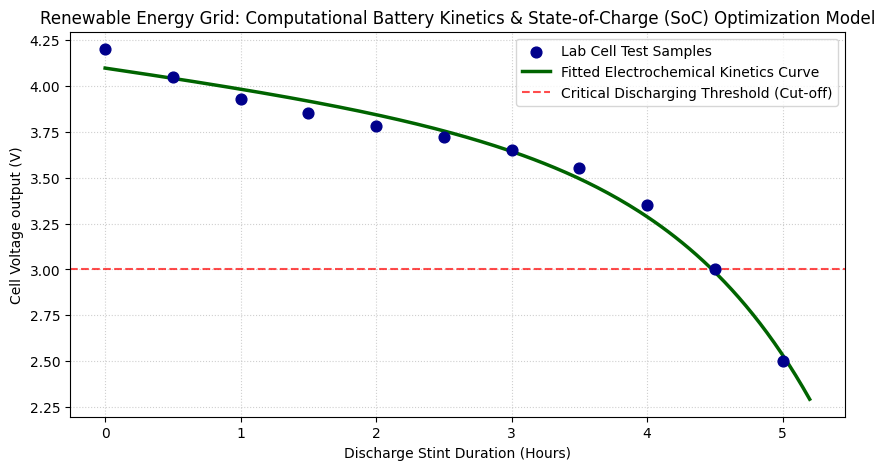


--- RENEWABLE ENERGY PROJECT SUCCESSFUL ---
Estimated Initial Voltage (V0): 4.107 V
Linear Discharge Decay Rate (k): 0.0995 V/hr
Exponential Chemical Depletion Factor (b): 0.9357


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Simulate empirical battery discharge curve data (Time in hours vs Voltage in Volts)
# Captures standard non-linear chemical voltage drops in lithium/flow batteries
time_hours = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
voltage_volts = np.array([4.2, 4.05, 3.93, 3.85, 3.78, 3.72, 3.65, 3.55, 3.35, 3.0, 2.5])

# 2. Define a Nernstian-style Electrochemical Degradation Model
def battery_discharge_model(t, V0, k, b):
    # Models initial linear drop + exponential chemical depletion drop at the tail end
    return V0 - k * t - 0.01 * np.exp(b * t)

# 3. Fit the kinetic model to the battery data
params, covariance = curve_fit(battery_discharge_model, time_hours, voltage_volts, p0=[4.2, 0.1, 1.0])
V0_est, k_est, b_est = params

# 4. Generate high-resolution optimization curve for mapping
time_fine = np.linspace(0, 5.2, 200)
fitted_voltage = battery_discharge_model(time_fine, V0_est, k_est, b_est)

# 5. Plot the Energy Optimization Graph
plt.figure(figsize=(10, 5))
plt.scatter(time_hours, voltage_volts, color='darkblue', label='Lab Cell Test Samples', s=60, zorder=3)
plt.plot(time_fine, fitted_voltage, color='darkgreen', linewidth=2.5, label='Fitted Electrochemical Kinetics Curve')
plt.axhline(y=3.0, color='red', linestyle='--', alpha=0.7, label='Critical Discharging Threshold (Cut-off)')
plt.title('Renewable Energy Grid: Computational Battery Kinetics & State-of-Charge (SoC) Optimization Model')
plt.xlabel('Discharge Stint Duration (Hours)')
plt.ylabel('Cell Voltage output (V)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n--- RENEWABLE ENERGY PROJECT SUCCESSFUL ---")
print(f"Estimated Initial Voltage (V0): {V0_est:.3f} V")
print(f"Linear Discharge Decay Rate (k): {k_est:.4f} V/hr")
print(f"Exponential Chemical Depletion Factor (b): {b_est:.4f}")
